In [12]:
!pip -q install \
lightkurve \
wotan \
astropy \
pyarrow \
scipy \
numpy \
pandas \
matplotlib \
plotly \
tqdm

In [13]:
import gc
import json
import logging
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.interpolate import interp1d

from astropy.stats import sigma_clip

from tqdm.notebook import tqdm

from wotan import flatten

warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [14]:
PROJECT_NAME = "Exoplanet-detection"

ROOT_DIR = Path("D:/MachineLearning") / PROJECT_NAME


RAW_DIR = ROOT_DIR / "data" / "raw" / "lightcurves"

PROCESSED_DIR = ROOT_DIR / "data" / "processed" / "lightcurves"

REPORT_DIR = ROOT_DIR / "reports"

LOG_DIR = ROOT_DIR / "logs"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

SIGMA = 5

WINDOW_LENGTH = 0.5

MAX_GAP = 0.02

NORMALIZATION = "median"

print("Configuration Loaded")

Configuration Loaded


In [15]:
LOG_FILE = LOG_DIR / "notebook_03.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE),
        logging.StreamHandler()
    ],
    force=True
)

logger = logging.getLogger("Notebook03")

logger.info("Notebook 03 Started")

2026-07-23 11:55:22,818 | INFO | Notebook 03 Started


In [16]:
import platform
import multiprocessing
import torch

print("Runtime Information")

print(f"{platform.python_version()}")
print(f"{multiprocessing.cpu_count()}")

if torch.cuda.is_available():
    print(f"{torch.cuda.get_device_name(0)}")
    print(f"{torch.version.cuda}")
else:
    print("GPU Not Available")


Runtime Information
3.12.10
16
NVIDIA GeForce RTX 3050 Laptop GPU
12.8


In [17]:
print(RAW_DIR / "TIC_273582656_Sector_81.parquet")
print("D:/MachineLearning/Exoplanet-detection/data/raw/lightcurves/TIC_273582656_Sector_81.parquet")

D:\MachineLearning\Exoplanet-detection\data\raw\lightcurves\TIC_273582656_Sector_81.parquet
D:/MachineLearning/Exoplanet-detection/data/raw/lightcurves/TIC_273582656_Sector_81.parquet


In [18]:
lightcurve_files = sorted(list(RAW_DIR.glob("*.parquet")))

print(f"Total Light Curves Found : {len(lightcurve_files):,}")

if len(lightcurve_files):

    print(lightcurve_files[0])

else:

    print("No light curves found.")
    
    

Total Light Curves Found : 89
D:\MachineLearning\Exoplanet-detection\data\raw\lightcurves\TIC_100990000_Sector_3.parquet


In [19]:
sample_df = pd.read_parquet(lightcurve_files[0])

sample_df.head()

,tic_id,sector,mission,author,target_name,cadence_sec,time,flux,flux_err,quality
0,100990000,3,TESS,SPOC,100990000,21.661595,1385.938475,128438.023438,40.047752,8192
1,100990000,3,TESS,SPOC,100990000,21.661595,1385.939864,128494.367188,40.059822,8192
2,100990000,3,TESS,SPOC,100990000,21.661595,1385.941253,128450.484375,40.066109,8192
3,100990000,3,TESS,SPOC,100990000,21.661595,1385.942642,128493.015625,40.056656,8192
4,100990000,3,TESS,SPOC,100990000,21.661595,1385.944031,128481.921875,40.063660,8192


In [20]:
print(sample_df.info())
display(sample_df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13541 entries, 0 to 13540
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   tic_id       13541 non-null  int64  
 1   sector       13541 non-null  int64  
 2   mission      13541 non-null  object 
 3   author       13541 non-null  object 
 4   target_name  13541 non-null  int64  
 5   cadence_sec  13541 non-null  float64
 6   time         13541 non-null  float64
 7   flux         13541 non-null  float32
 8   flux_err     13541 non-null  float32
 9   quality      13541 non-null  int32  
dtypes: float32(2), float64(2), int32(1), int64(3), object(2)
memory usage: 899.3+ KB
None


,tic_id,sector,mission,author,target_name,cadence_sec,time,flux,flux_err,quality
count,13541.0,13541.0,13541,13541,13541.0,1.354100e+04,13541.000000,13541.000000,13541.000000,13541.000000
unique,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,TESS,SPOC,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,13541,13541,NaN,NaN,NaN,NaN,NaN,NaN
mean,100990000.0,3.0,NaN,NaN,100990000.0,2.166159e+01,1396.078875,128491.093750,40.117218,5.444797
std,0.0,0.0,NaN,NaN,0.0,7.105690e-15,6.041464,41.288769,0.236199,211.133668
min,100990000.0,3.0,NaN,NaN,100990000.0,2.166159e+01,1385.938475,128336.007812,40.024460,0.000000
25%,100990000.0,3.0,NaN,NaN,100990000.0,2.166159e+01,1390.694145,128463.593750,40.049999,0.000000
50%,100990000.0,3.0,NaN,NaN,100990000.0,2.166159e+01,1396.702592,128490.781250,40.057373,0.000000
75%,100990000.0,3.0,NaN,NaN,100990000.0,2.166159e+01,1401.448507,128518.390625,40.065369,0.000000


In [21]:
#missing values 
missing = sample_df.isnull().sum()

display(missing)


tic_id         0
sector         0
mission        0
author         0
target_name    0
cadence_sec    0
time           0
flux           0
flux_err       0
quality        0
dtype: int64

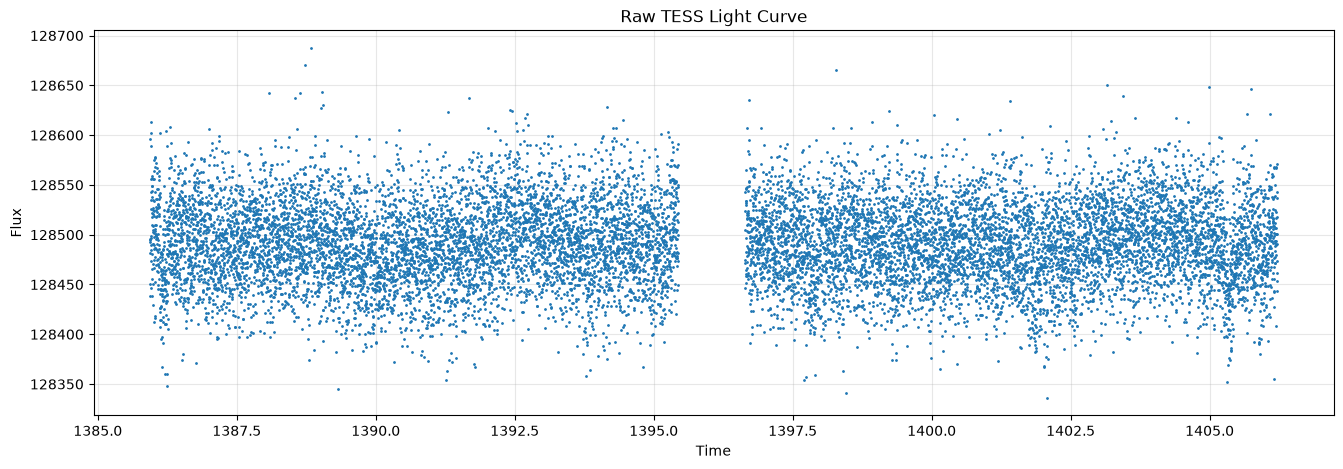

In [22]:
# Visualization initialization
plt.figure(figsize=(16,5))

plt.plot(
    sample_df["time"],
    sample_df["flux"],
    ".",
    markersize=2
)

plt.xlabel("Time")

plt.ylabel("Flux")

plt.title("Raw TESS Light Curve")

plt.grid(alpha=0.3)

plt.show()

In [23]:
def filter_quality_flags(df):
    """
    Keep only observations with QUALITY == 0.
    """

    original_points = len(df)

    if "quality" in df.columns:
        df = df[df["quality"] == 0].copy()

    removed = original_points - len(df)

    return df, removed

In [24]:
def remove_missing_values(df):
    """
    Remove rows containing NaN values in time or flux.
    """

    original_points = len(df)

    df = df.dropna(
        subset=[
            "time",
            "flux",
            "flux_err"
        ]
    )

    removed = original_points - len(df)

    return df, removed

In [25]:
def remove_duplicate_times(df):
    """
    Remove duplicate timestamps.
    """

    original_points = len(df)

    df = df.drop_duplicates(
        subset="time"
    )

    removed = original_points - len(df)

    return df, removed

In [26]:
def sort_time(df):
    """
    Ensure chronological ordering.
    """

    df = df.sort_values(
        by="time"
    ).reset_index(drop=True)

    return df

In [27]:
# Sigma clipping

def sigma_clipping(df, sigma=5):

    clipped = sigma_clip(
        df["flux"],
        sigma=sigma
    )

    mask = ~clipped.mask

    removed = len(df) - mask.sum()

    df = df[mask].reset_index(drop=True)

    return df, removed

In [28]:
#Normalization 
def normalize_flux(df):

    median_flux = np.nanmedian(df["flux"])

    df["flux"] = df["flux"] / median_flux

    df["flux_err"] = df["flux_err"] / median_flux

    return df

In [29]:
#Wotan detrending

def detrend_lightcurve(df):

    flattened_flux, trend = flatten(
        df["time"].values,
        df["flux"].values,
        method="biweight",
        window_length=0.5,
        return_trend=True
    )

    df["trend"] = trend
    df["flux"] = flattened_flux

    return df

In [30]:
#Interpolating small gaps 


def interpolate_flux(df):

    df["flux"] = (
        df["flux"]
        .interpolate(
            method="linear",
            limit_direction="both"
        )
    )

    df["flux_err"] = (
        df["flux_err"]
        .interpolate(
            method="linear",
            limit_direction="both"
        )
    )

    return df

In [31]:
# Validation 

def validate_lightcurve(df):

    checks = {

        "Rows": len(df),

        "NaNs": int(df.isnull().sum().sum()),

        "Duplicate Times": int(
            df["time"].duplicated().sum()
        ),

        "Median Flux": float(
            np.nanmedian(df["flux"])
        ),

        "Flux Std": float(
            np.nanstd(df["flux"])
        )

    }

    return checks

In [32]:
# Complete Preprocessing 


def preprocess_lightcurve(df):

    report = {}

    report["original_points"] = len(df)

    df, removed = filter_quality_flags(df)
    report["quality_removed"] = removed

    df, removed = remove_missing_values(df)
    report["nan_removed"] = removed

    df, removed = remove_duplicate_times(df)
    report["duplicate_removed"] = removed

    df = sort_time(df)

    df, removed = sigma_clipping(df)
    report["sigma_removed"] = removed

    df = detrend_lightcurve(df)

    df = normalize_flux(df)

    df = interpolate_flux(df)

    report.update(validate_lightcurve(df))

    return df, report

In [33]:
processed_df, report = preprocess_lightcurve(sample_df.copy())

print(report)

processed_df.head()

{'original_points': 13541, 'quality_removed': 9, 'nan_removed': 0, 'duplicate_removed': 0, 'sigma_removed': np.int64(0), 'Rows': 13532, 'NaNs': 0, 'Duplicate Times': 0, 'Median Flux': 1.0, 'Flux Std': 0.00031573743417790046}


,tic_id,sector,mission,author,target_name,cadence_sec,time,flux,flux_err,quality,trend
0,100990000,3,TESS,SPOC,100990000,21.661595,1385.950975,0.999648,40.051029,0,128491.154483
1,100990000,3,TESS,SPOC,100990000,21.661595,1385.952364,1.000761,40.076237,0,128491.278858
2,100990000,3,TESS,SPOC,100990000,21.661595,1385.953753,1.000269,40.061535,0,128491.029725
3,100990000,3,TESS,SPOC,100990000,21.661595,1385.955142,0.999865,40.054287,0,128490.664490
4,100990000,3,TESS,SPOC,100990000,21.661595,1385.956531,1.000046,40.054855,0,128490.364681


In [34]:
# Processing a single light curve 

def process_file(file_path):

    try:

        df = pd.read_parquet(file_path)

        processed_df, report = preprocess_lightcurve(df)

        output_file = PROCESSED_DIR / file_path.name

        processed_df.to_parquet(
            output_file,
            index=False
        )

        report["file_name"] = file_path.name

        report["status"] = "Success"

        return report

    except Exception as e:

        logger.error(f"{file_path.name} : {e}")

        return {

            "file_name": file_path.name,

            "status": "Failed",

            "error": str(e)

        }
        

In [35]:
# Batch processing 

processing_reports = []

for file_path in tqdm(lightcurve_files):

    report = process_file(file_path)

    processing_reports.append(report)

    gc.collect()

print("Processing Complete")


  0%|          | 0/89 [00:00<?, ?it/s]

Processing Complete


In [36]:
# Processing report 

processing_report = pd.DataFrame(processing_reports)

processing_report.head()

,original_points,quality_removed,nan_removed,duplicate_removed,sigma_removed,Rows,NaNs,Duplicate Times,Median Flux,Flux Std,file_name,status
0,13541,9,0,0,0,13532,0,0,1.0,0.000316,TIC_100990000_Sector_3.parquet,Success
1,19611,0,0,0,0,19611,0,0,1.0,0.008784,TIC_120252452_Sector_40.parquet,Success
2,17303,311,0,0,1,16991,0,0,1.0,0.014823,TIC_120422519_Sector_53.parquet,Success
3,18556,1300,0,0,1,17255,0,0,1.0,0.018543,TIC_120691237_Sector_80.parquet,Success
4,19610,0,0,0,1,19609,0,0,1.0,0.019285,TIC_121395761_Sector_40.parquet,Success


In [37]:
print(REPORT_DIR)

D:\MachineLearning\Exoplanet-detection\reports


In [38]:
# Saving the processing report 

report_path = REPORT_DIR / "preprocessing_report.csv"

processing_report.to_csv(
    report_path,
    index=False
)

logger.info("Processing report saved.")

2026-07-23 11:58:50,868 | INFO | Processing report saved.


In [39]:
# Loading one processed Light curve 

processed_files = sorted(PROCESSED_DIR.glob("*.parquet"))

processed_sample = pd.read_parquet(
    processed_files[0]
)

processed_sample.head()

,tic_id,sector,mission,author,target_name,cadence_sec,time,flux,flux_err,quality,trend
0,100990000,3,TESS,SPOC,100990000,21.661595,1385.950975,0.999648,40.051029,0,128491.154483
1,100990000,3,TESS,SPOC,100990000,21.661595,1385.952364,1.000761,40.076237,0,128491.278858
2,100990000,3,TESS,SPOC,100990000,21.661595,1385.953753,1.000269,40.061535,0,128491.029725
3,100990000,3,TESS,SPOC,100990000,21.661595,1385.955142,0.999865,40.054287,0,128490.664490
4,100990000,3,TESS,SPOC,100990000,21.661595,1385.956531,1.000046,40.054855,0,128490.364681


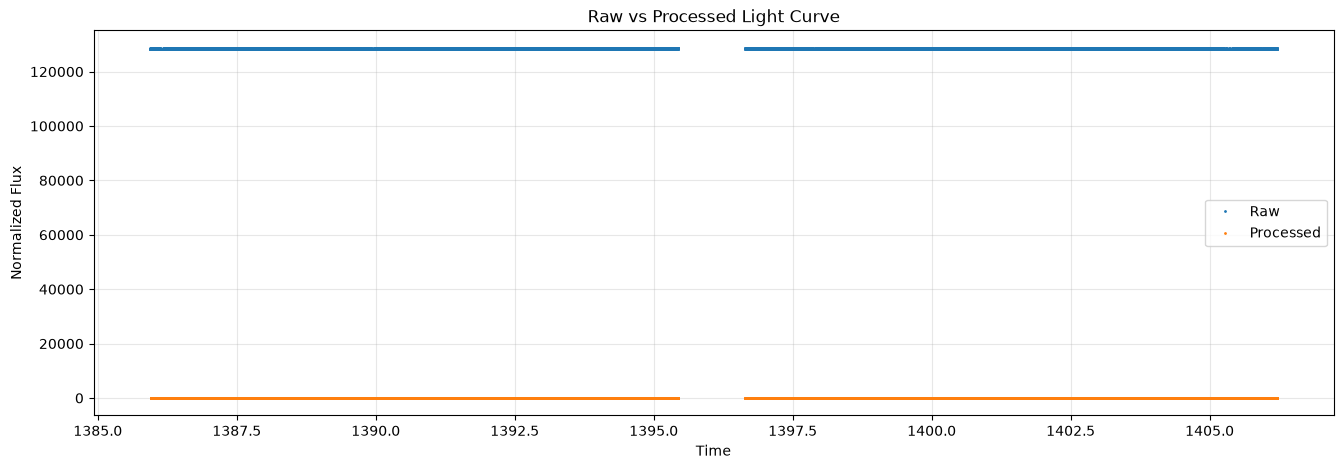

In [40]:
# Before v/s after visualization 

raw_sample = pd.read_parquet(lightcurve_files[0])

plt.figure(figsize=(16,5))

plt.plot(
    raw_sample["time"],
    raw_sample["flux"],
    ".",
    markersize=2,
    label="Raw"
)

plt.plot(
    processed_sample["time"],
    processed_sample["flux"],
    ".",
    markersize=2,
    label="Processed"
)

plt.xlabel("Time")

plt.ylabel("Normalized Flux")

plt.title("Raw vs Processed Light Curve")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

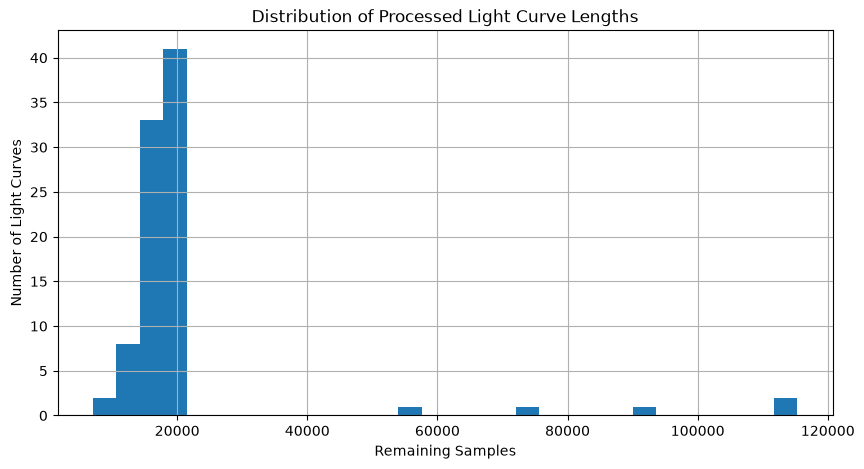

In [41]:
# Report distribution 

if "Rows" in processing_report.columns:

    plt.figure(figsize=(10,5))

    processing_report["Rows"].hist(
        bins=30
    )

    plt.xlabel("Remaining Samples")

    plt.ylabel("Number of Light Curves")

    plt.title("Distribution of Processed Light Curve Lengths")

    plt.show()

In [43]:
# Saved notebook metadata

metadata = {

    "Notebook": "03_Light_Curve_Preprocessing",

    "Execution Time": str(datetime.now()),

    "Processed Files": int(len(processing_report)),

    "Successful": int((processing_report["status"]=="Success").sum()),

    "Failed": int((processing_report["status"]=="Failed").sum()),

    "Sigma": SIGMA,

    "Detrending": "Wotan Biweight",

    "Normalization": "Median"

}

with open(
    REPORT_DIR / "preprocessing_metadata.json",
    "w"
) as f:

    json.dump(metadata, f, indent=4)

logger.info("Metadata saved.") 

2026-07-23 12:01:00,042 | INFO | Metadata saved.


In [44]:
print("Notebook 03 Completed Successfully")

print(f"Processed Files : {len(processed_files)}")

print(f"Report File     : {report_path}")

print(f"Metadata File   : {REPORT_DIR/'preprocessing_metadata.json'}")

print(f"Output Folder   : {PROCESSED_DIR}")

logger.info("Notebook 03 Completed Successfully")

2026-07-23 12:01:29,611 | INFO | Notebook 03 Completed Successfully


Notebook 03 Completed Successfully
Processed Files : 89
Report File     : D:\MachineLearning\Exoplanet-detection\reports\preprocessing_report.csv
Metadata File   : D:\MachineLearning\Exoplanet-detection\reports\preprocessing_metadata.json
Output Folder   : D:\MachineLearning\Exoplanet-detection\data\processed\lightcurves
